# Gait Classifier for All 82 Features

## 1. Load extracted features

In [1]:
from ambient.classification.features import GaitFeatureVector
from ambient.utils.features_utils import load_features

FILENAME="all82_features.pkl"
DIRECTORY="features"

all_features, condition_counts = load_features(filename=FILENAME, directory=DIRECTORY)
print(f"\n{'='*60}")
print(f"Total features loaded: {len(all_features)}")
print(f"\nCondition distribution:")
for condition, count in sorted(condition_counts.items()):
     print(f"  {condition:15s}: {count:3d} samples")

✓ Features loaded successfully from: features/all82_features.pkl
  Saved on: 2026-01-27T18:18:09.623427
  Total features: 68
  Conditions: ['stroke', 'myopathic', 'parkinsons', 'normal', 'cerebralpalsy']

Total features loaded: 68

Condition distribution:
  cerebralpalsy  :  15 samples
  myopathic      :  20 samples
  normal         :  12 samples
  parkinsons     :   9 samples
  stroke         :  12 samples


In [15]:
print(f"# Samples: {len(all_features)}, type: {type(all_features[0])}")

# Samples: 68, type: <class 'ambient.classification.features.GaitFeatureVector'>


In [ ]:
all_features[0].get_feature_names(), len(all_features[0].get_feature_names())

(['left_hip_mean',
  'left_knee_mean',
  'left_ankle_mean',
  'right_hip_mean',
  'right_knee_mean',
  'right_ankle_mean',
  'hip_asymmetry',
  'knee_asymmetry',
  'ankle_asymmetry',
  'left_hip_range',
  'left_knee_range',
  'left_ankle_range',
  'right_hip_range',
  'right_knee_range',
  'right_ankle_range',
  'walking_speed_ms',
  'cadence_steps_min',
  'stride_length_m',
  'step_width_m',
  'stance_percentage',
  'swing_percentage',
  'double_support_percentage',
  'stance_swing_ratio',
  'stride_length_si',
  'stance_time_si',
  'swing_time_si',
  'hip_angle_si',
  'knee_angle_si',
  'ankle_angle_si',
  'velocity_mean',
  'velocity_std',
  'velocity_max',
  'velocity_min',
  'acceleration_mean',
  'acceleration_std',
  'acceleration_max',
  'jerk_mean',
  'jerk_std',
  'stride_time_cv',
  'step_length_cv',
  'stride_velocity_cv',
  'trunk_lean_angle',
  'pelvic_tilt_mean',
  'left_hip_std',
  'left_knee_std',
  'left_ankle_std',
  'right_hip_std',
  'right_knee_std',
  'right_ankl

## 2. Splitting Training vs Testing datasets

In [32]:
import numpy as np

In [33]:
def get_train_test(all_features: list, train_portion: float = 0.8):
    np.random.seed(42)
    split_idx = int( train_portion * len(all_features) )

    indices = np.random.permutation(len(all_features))

    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]

    train_features = [all_features[i] for i in train_indices]
    test_features = [all_features[i] for i in test_indices]
    
    return train_features, test_features

In [34]:
all_features = [f for f in all_features if f is not None]

In [35]:
train_features, test_features = get_train_test(all_features, 0.7)

len(train_features), len(test_features), len(all_features)

(47, 21, 68)

## 3. Classification with KNN

In [36]:
from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig
)

In [37]:
config = KNNClassifierConfig(
    n_neighbors=3,
    weights="distance",
    metric="euclidean",
    normalize_features=True
)

In [38]:
knn_classifier = KNNGaitClassifier(config=config)

2026-01-27 20:19:11.106 | INFO     | ambient.classification.knn_classifier:__init__:87 - KNN classifier initialized with k=3


### Training

In [39]:
%%time

knn_metrics = knn_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

2026-01-27 20:19:12.707 | INFO     | ambient.classification.base_classifier:train:136 - Training KNNGaitClassifier with 47 samples
2026-01-27 20:19:12.709 | INFO     | ambient.classification.base_classifier:train:137 - Feature shape: (47, 82)
2026-01-27 20:19:12.710 | INFO     | ambient.classification.base_classifier:train:138 - Classes: ['cerebralpalsy' 'myopathic' 'normal' 'parkinsons' 'stroke']
2026-01-27 20:19:12.711 | INFO     | ambient.classification.base_classifier:train:220 - Class distribution: {np.str_('cerebralpalsy'): np.int64(10), np.str_('myopathic'): np.int64(13), np.str_('normal'): np.int64(9), np.str_('parkinsons'): np.int64(6), np.str_('stroke'): np.int64(9)}
2026-01-27 20:19:12.715 | INFO     | ambient.classification.base_classifier:train:225 - Features normalized using StandardScaler
2026-01-27 20:19:12.776 | INFO     | ambient.classification.base_classifier:train:291 - Cross-validation accuracy: 0.442 ± 0.124
2026-01-27 20:19:12.777 | INFO     | ambient.classificat

CPU times: user 27.4 ms, sys: 25.3 ms, total: 52.7 ms
Wall time: 70.7 ms


### Evaluation

In [40]:
eval_metrics = knn_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:14.742 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 1.000
2026-01-27 20:19:14.743 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 1.000


Eval accuracy: 1.0


In [41]:
eval_metrics = knn_classifier.evaluate(test_features=test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:15.747 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 0.571
2026-01-27 20:19:15.747 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 0.486


Eval accuracy: 0.5714285714285714


In [42]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


cerebralpalsy
  F1-Score : 0.545
  Precision: 0.500
  Recall   : 0.600

myopathic
  F1-Score : 0.750
  Precision: 0.667
  Recall   : 0.857

normal
  F1-Score : 0.800
  Precision: 1.000
  Recall   : 0.667

parkinsons
  F1-Score : 0.333
  Precision: 0.333
  Recall   : 0.333

stroke
  F1-Score : 0.000
  Precision: 0.000
  Recall   : 0.000


### Evaluation Confusion Matrix

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

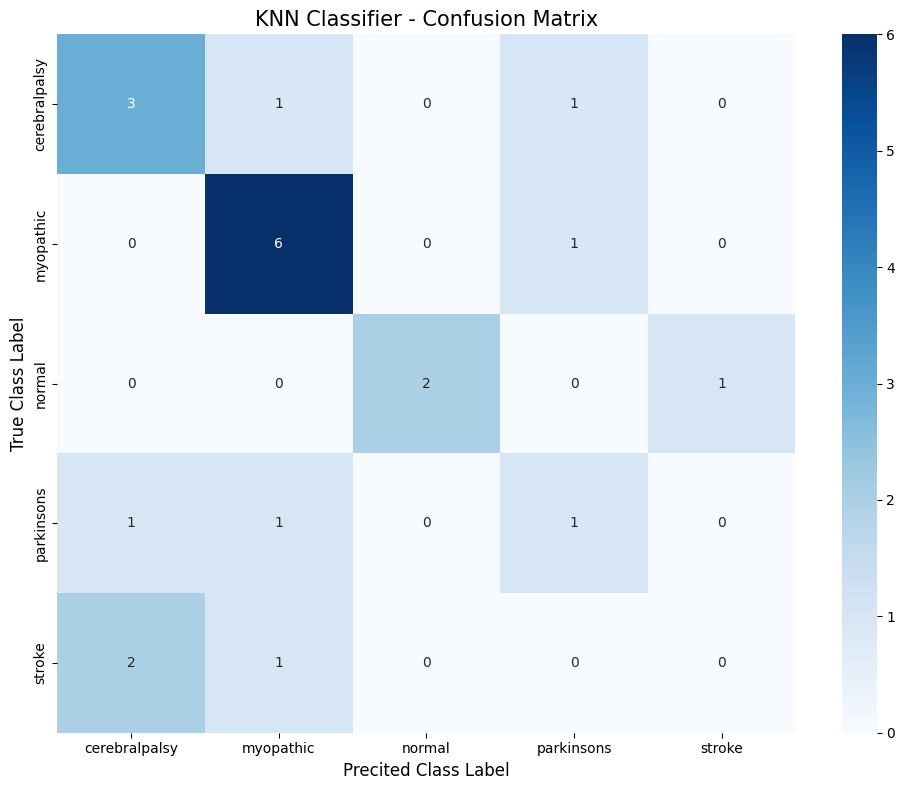

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title('KNN Classifier - Confusion Matrix', fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Classification with Decision Tree

In [45]:
from ambient.classification.decisiontree_classifier import(
    DecisionTreeGaitClassifier,
    DecisionTreeClassifierConfig
)

In [46]:
dt_config = DecisionTreeClassifierConfig(
    criterion='gini',
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    class_weight='balanced',
    normalize_features=True,
    random_state=42
)

dt_classifier = DecisionTreeGaitClassifier(dt_config)

2026-01-27 20:19:27.980 | INFO     | ambient.classification.decisiontree_classifier:__init__:84 - Decision Tree classifier initialized with gini criterion


### Training

In [47]:
%%time 

dt_metrics = dt_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

print(f"training accuracy: {dt_metrics['train_accuracy']}")

2026-01-27 20:19:29.296 | INFO     | ambient.classification.base_classifier:train:136 - Training DecisionTreeGaitClassifier with 47 samples
2026-01-27 20:19:29.297 | INFO     | ambient.classification.base_classifier:train:137 - Feature shape: (47, 82)
2026-01-27 20:19:29.298 | INFO     | ambient.classification.base_classifier:train:138 - Classes: ['cerebralpalsy' 'myopathic' 'normal' 'parkinsons' 'stroke']
2026-01-27 20:19:29.299 | INFO     | ambient.classification.base_classifier:train:220 - Class distribution: {np.str_('cerebralpalsy'): np.int64(10), np.str_('myopathic'): np.int64(13), np.str_('normal'): np.int64(9), np.str_('parkinsons'): np.int64(6), np.str_('stroke'): np.int64(9)}
2026-01-27 20:19:29.300 | INFO     | ambient.classification.base_classifier:train:225 - Features normalized using StandardScaler
2026-01-27 20:19:29.313 | INFO     | ambient.classification.base_classifier:train:291 - Cross-validation accuracy: 0.489 ± 0.160
2026-01-27 20:19:29.313 | INFO     | ambient.cl

training accuracy: 0.8085106382978723
CPU times: user 67.3 ms, sys: 14.2 ms, total: 81.4 ms
Wall time: 87.1 ms


### Evaluation

In [48]:
eval_metrics = dt_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:30.360 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 0.809
2026-01-27 20:19:30.360 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 0.824


Eval accuracy: 0.8085106382978723


In [49]:
eval_metrics = dt_classifier.evaluate(test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:31.107 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 0.571
2026-01-27 20:19:31.107 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 0.474


Eval accuracy: 0.5714285714285714


In [50]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


cerebralpalsy
  F1-Score : 0.571
  Precision: 1.000
  Recall   : 0.400

myopathic
  F1-Score : 0.800
  Precision: 0.750
  Recall   : 0.857

normal
  F1-Score : 0.500
  Precision: 0.400
  Recall   : 0.667

parkinsons
  F1-Score : 0.500
  Precision: 0.400
  Recall   : 0.667

stroke
  F1-Score : 0.000
  Precision: 0.000
  Recall   : 0.000


### Evaluation Confusion Matrix

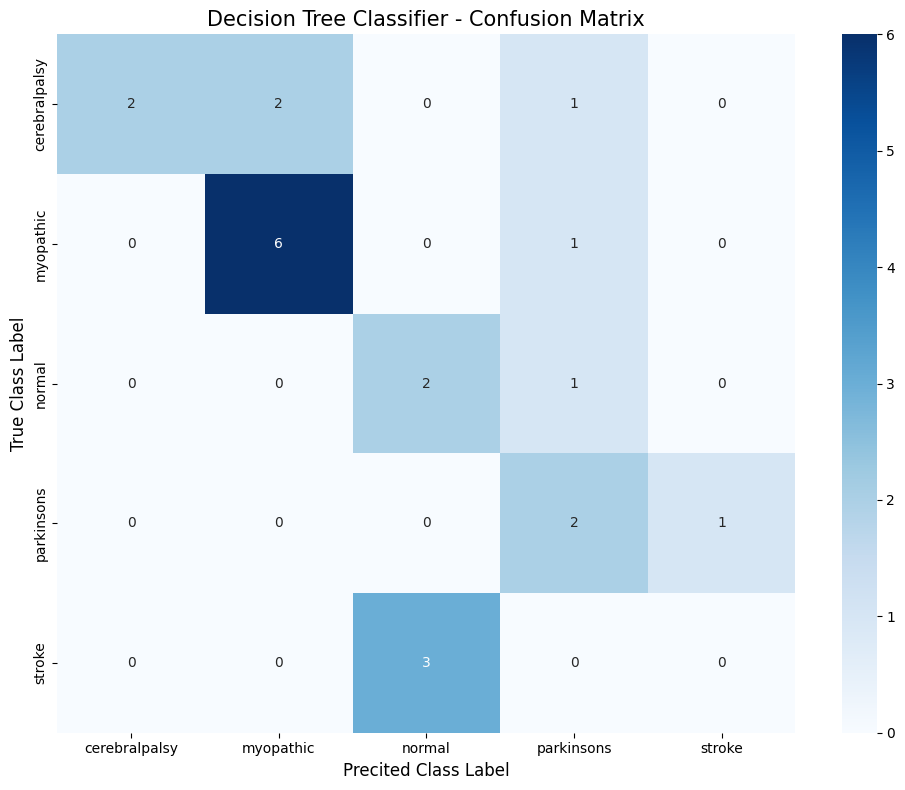

In [51]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title('Decision Tree Classifier - Confusion Matrix', fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()

### Visualize Decision Tree

In [52]:
if 'feature_importances' in dt_metrics:
    print("Top 5 Most Important Features:")
    for feat in dt_metrics['feature_importances'][:5]:
        print(f"    {feat['rank']}. {feat['feature']:20s}: {feat['importance']:.3f}")

Top 5 Most Important Features:
    1. step_length_cv      : 0.221
    2. swing_percentage    : 0.190
    3. left_cycle_duration_mean: 0.141
    4. com_stability_index : 0.140
    5. duration_seconds    : 0.115


✓ Got feature names from GaitFeatureVector: 82 features


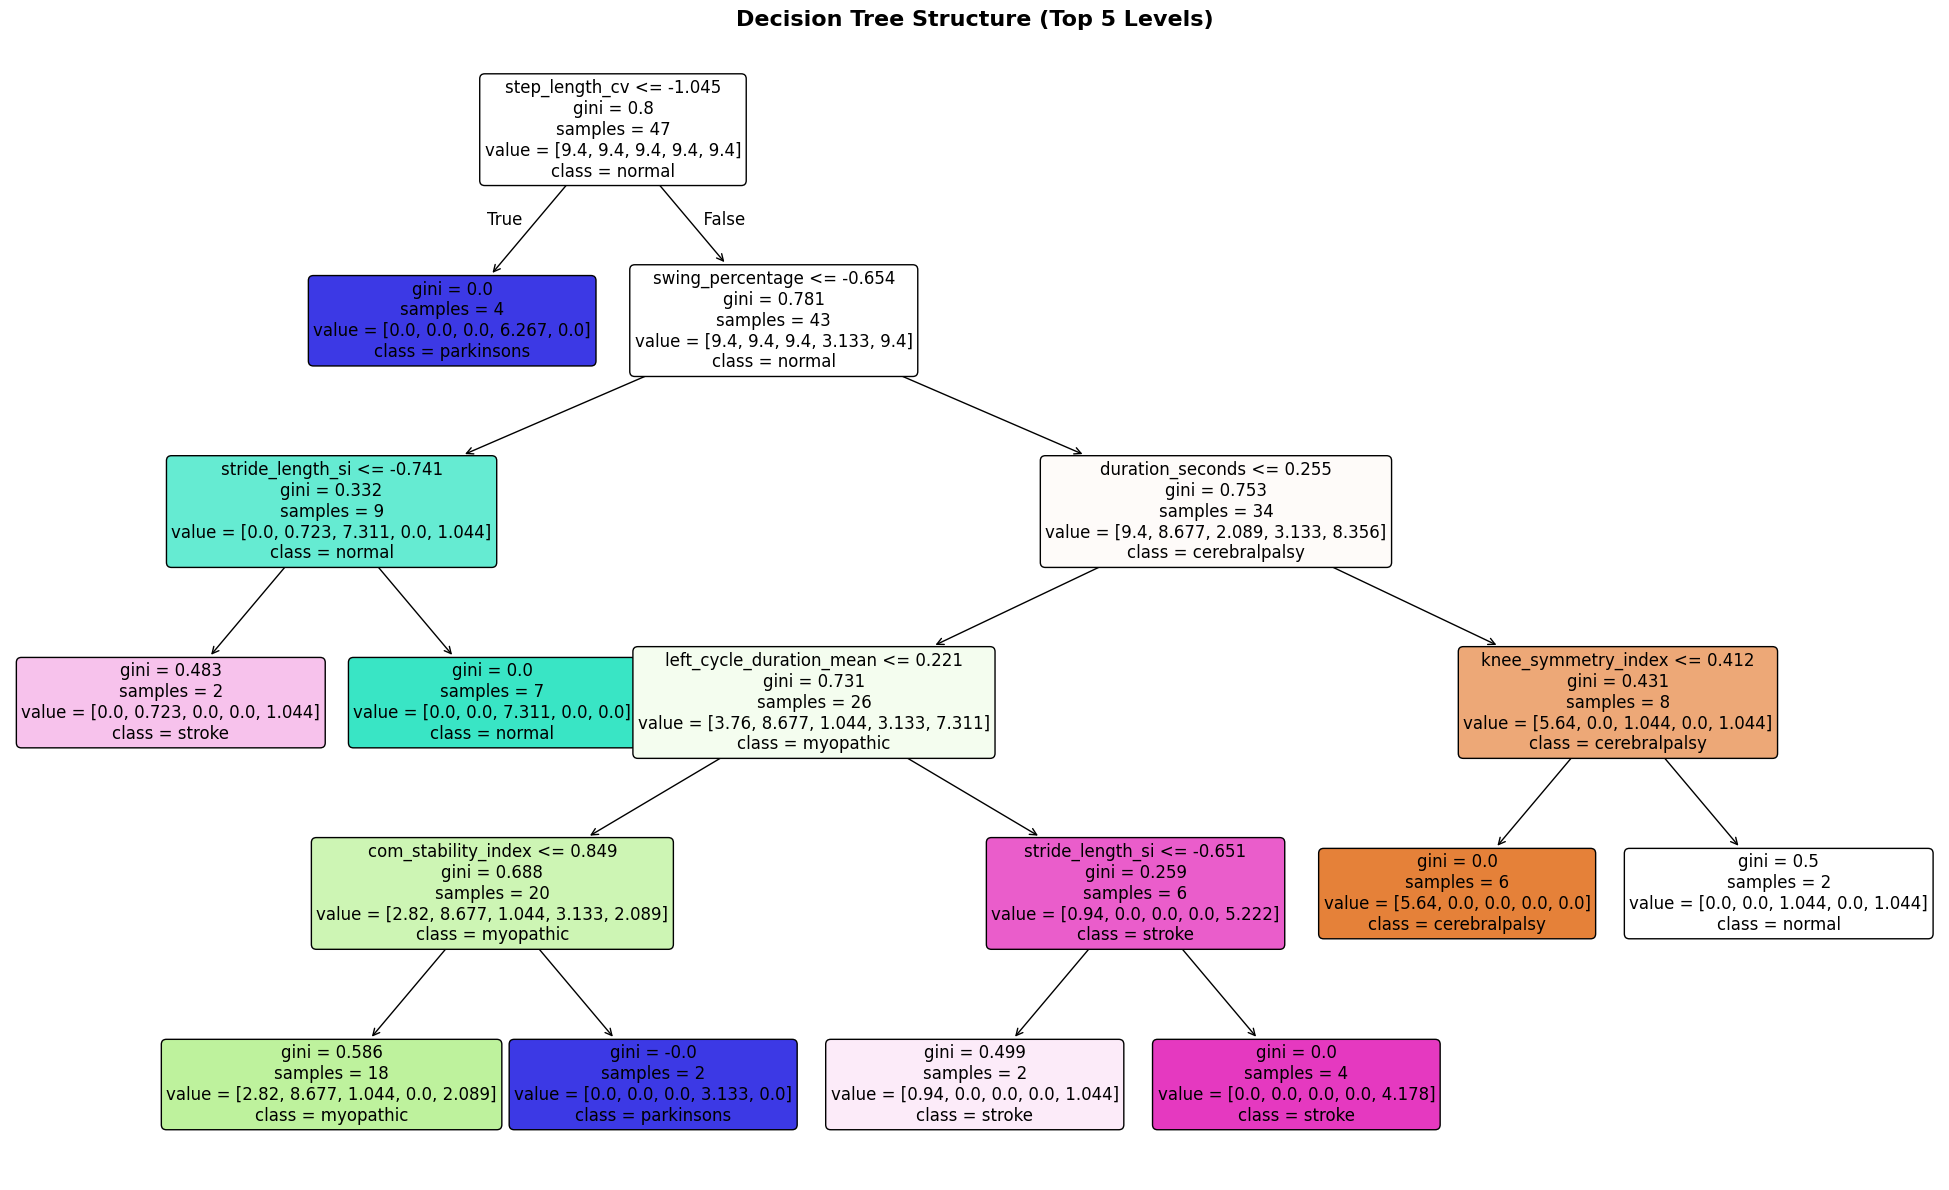

In [53]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get the underlying sklearn model
sklearn_model = dt_classifier.model

# Method 1: Try to get feature names from GaitFeatureVector
try:
    feature_names = GaitFeatureVector.get_feature_names()
    print(f"✓ Got feature names from GaitFeatureVector: {len(feature_names)} features")
except AttributeError:
    print("GaitFeatureVector.get_feature_names() not available, trying alternatives...")
    
    # Method 2: Extract from sample feature vector
    if train_features:
        sample_feature = train_features[0]
        try:
            feature_names = sample_feature.get_feature_names()
            print(f"✓ Got feature names from sample feature: {len(feature_names)} features")
        except AttributeError:
            # Method 3: Extract from feature vector attributes
            if hasattr(sample_feature, '__dict__'):
                feature_names = [attr for attr in sample_feature.__dict__.keys() 
                               if not attr.startswith('_') and attr not in ['condition_label', 'sample_id']]
                print(f"✓ Extracted feature names from attributes: {len(feature_names)} features")
            else:
                # Method 4: Fallback to generic names
                n_features = len(sample_feature.to_array()) if hasattr(sample_feature, 'to_array') else sklearn_model.n_features_in_
                feature_names = [f'feature_{i}' for i in range(n_features)]
                print(f"✓ Using generic feature names: {len(feature_names)} features")

# Get class names
class_names = eval_metrics['classes']

### 5.1 Visual Tree Plot
plt.figure(figsize=(20, 12))
plot_tree(sklearn_model, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=12,
          max_depth=5,  # Limit depth for readability
)
plt.title('Decision Tree Structure (Top 5 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Classification with Random Forest

In [54]:
from ambient.classification.rf_classifier import (
    RFClassifierConfig,
    RFGaitClassifier
)

In [55]:
rf_config = RFClassifierConfig(
    n_estimators = 100,
    max_depth = 5,
)

rf_classifier = RFGaitClassifier(rf_config)

2026-01-27 20:19:37.532 | INFO     | ambient.classification.rf_classifier:__init__:116 - Random Forest classifier initialized with 100 trees


### Training

In [56]:
%%time 

rf_metrics = rf_classifier.train(
    features=train_features,
    validate=True,
    auto_remove_invalid=True
)

print(f"training accuracy: {rf_metrics['train_accuracy']}")

2026-01-27 20:19:37.983 | INFO     | ambient.classification.base_classifier:train:136 - Training RFGaitClassifier with 47 samples
2026-01-27 20:19:37.984 | INFO     | ambient.classification.base_classifier:train:137 - Feature shape: (47, 82)
2026-01-27 20:19:37.985 | INFO     | ambient.classification.base_classifier:train:138 - Classes: ['cerebralpalsy' 'myopathic' 'normal' 'parkinsons' 'stroke']
2026-01-27 20:19:37.986 | INFO     | ambient.classification.base_classifier:train:220 - Class distribution: {np.str_('cerebralpalsy'): np.int64(10), np.str_('myopathic'): np.int64(13), np.str_('normal'): np.int64(9), np.str_('parkinsons'): np.int64(6), np.str_('stroke'): np.int64(9)}
2026-01-27 20:19:37.987 | INFO     | ambient.classification.base_classifier:train:225 - Features normalized using StandardScaler
2026-01-27 20:19:38.463 | INFO     | ambient.classification.base_classifier:train:291 - Cross-validation accuracy: 0.571 ± 0.157
2026-01-27 20:19:38.464 | INFO     | ambient.classificati

training accuracy: 1.0
CPU times: user 410 ms, sys: 78.1 ms, total: 488 ms
Wall time: 517 ms


### Evaluation

In [57]:
eval_metrics = rf_classifier.evaluate(train_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:38.523 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 1.000
2026-01-27 20:19:38.524 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 1.000


Eval accuracy: 1.0


In [58]:
eval_metrics = rf_classifier.evaluate(test_features)
print(f"Eval accuracy: {eval_metrics['accuracy']}")

2026-01-27 20:19:38.758 | INFO     | ambient.classification.base_classifier:evaluate:409 - Test accuracy: 0.762
2026-01-27 20:19:38.759 | INFO     | ambient.classification.base_classifier:evaluate:410 - Test F1 score: 0.728


Eval accuracy: 0.7619047619047619


In [59]:
report = eval_metrics['classification_report']
for class_name in eval_metrics['classes']:
    cm = report[class_name]
    print(f"\n{class_name}")
    print(f"  F1-Score : {cm['f1-score']:.3f}")
    print(f"  Precision: {cm['precision']:.3f}")
    print(f"  Recall   : {cm['recall']:.3f}")    


cerebralpalsy
  F1-Score : 0.600
  Precision: 0.600
  Recall   : 0.600

myopathic
  F1-Score : 0.875
  Precision: 0.778
  Recall   : 1.000

normal
  F1-Score : 1.000
  Precision: 1.000
  Recall   : 1.000

parkinsons
  F1-Score : 0.667
  Precision: 0.667
  Recall   : 0.667

stroke
  F1-Score : 0.500
  Precision: 1.000
  Recall   : 0.333


### Evaluation Confusion Matrix

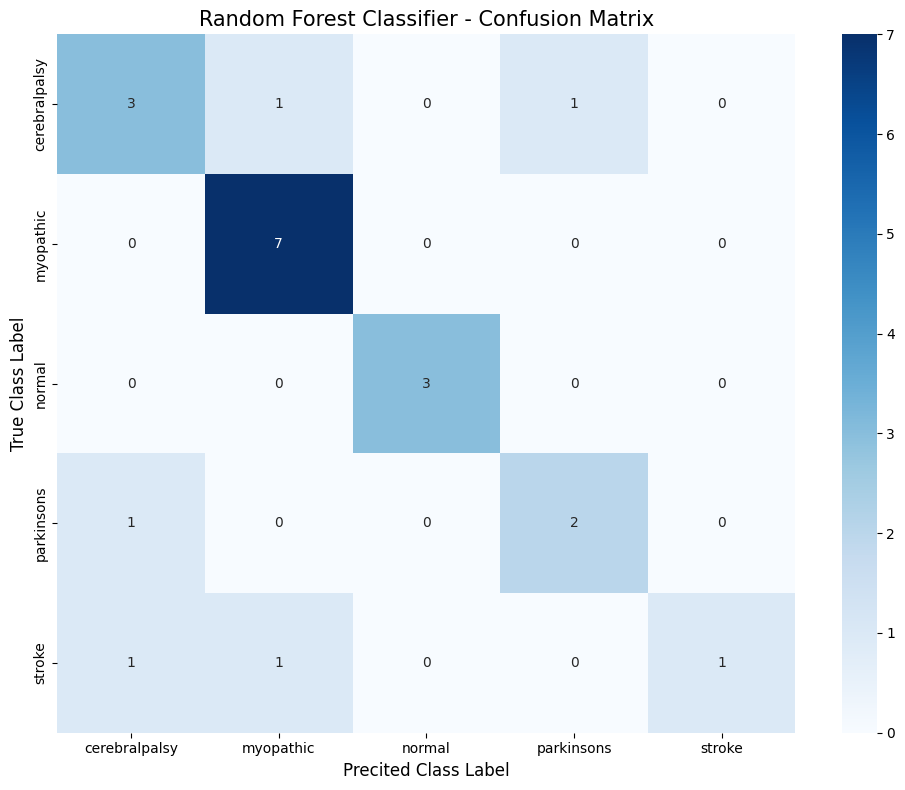

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(
    eval_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_metrics['classes'],
    yticklabels=eval_metrics['classes']
)
plt.title('Random Forest Classifier - Confusion Matrix', fontsize=15)
plt.ylabel('True Class Label', fontsize=12)
plt.xlabel('Precited Class Label', fontsize=12)
plt.tight_layout()
plt.show()